In [1]:
# Imports.
import numpy as np;
import xarray as xr;
import matplotlib.pyplot as plt;
import h5_reader_xr as reader;
import gysela_utilities as gys_utils;
import phi2D_utilities as utils;
import phi2D_analytical as analytical;
import gam_specialised.damping as damping;
from scipy.signal import find_peaks;

# Styling.
plt.style.use("bmh");

In [2]:
# Test inputs - delete when done!
path_prefix = "/zhisongqu_data/seth/GYSELA/raw/batch_11/"
perturbed_case_directory_path = "DN_DELTASCAN_A3_PERTURB_0.3";
quiescent_case_directory_path = "DN_DELTASCAN_A3_QUIESCENT_0.3";
perturbed_case_data_arrays = reader.fetch_phi2D_data(f"{path_prefix}{perturbed_case_directory_path}", parallelise = True);
quiescent_case_data_arrays = reader.fetch_phi2D_data(f"{path_prefix}{quiescent_case_directory_path}", parallelise = True) if quiescent_case_directory_path is not None else None;
dt_diag = reader.fetch_dt_diag(f"{path_prefix}{perturbed_case_directory_path}");
jacobian_dictionary = reader.fetch_jacobian(f"{path_prefix}{perturbed_case_directory_path}");

Found 1201 files in the directory. Loading with 16 workers...


[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    1.0s
[Parallel(n_jobs=16)]: Done 368 tasks      | elapsed:    2.1s
[Parallel(n_jobs=16)]: Done 1170 out of 1201 | elapsed:    4.3s remaining:    0.1s
[Parallel(n_jobs=16)]: Done 1201 out of 1201 | elapsed:    4.4s finished


Finished compiling data from all files in the directory.
Found 1201 files in the directory. Loading with 16 workers...


[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.1s
[Parallel(n_jobs=16)]: Done 512 tasks      | elapsed:    2.4s
[Parallel(n_jobs=16)]: Done 1201 out of 1201 | elapsed:    4.9s finished


Finished compiling data from all files in the directory.


In [5]:
effective_radius_simple = 0.49;
GAM_frequency = utils.extract_gam_frequency(perturbed_case_data_arrays, dt_diag, jacobian_dictionary, effective_radius_simple);
print(f"Squeakquency: {GAM_frequency}")
print(f"Squeakquency (omega): {2 * np.pi * GAM_frequency}");

Squeakquency: 0.0007893422148209826
Squeakquency (omega): 0.0049595834064997905


Damping rate: -3.93879731378567e-05


/home/thur0011/GYSELA/custom_scripts/GYSELA_utils/post-processing/scripts/gam_specialised/damping.py:170: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(loc="upper left");


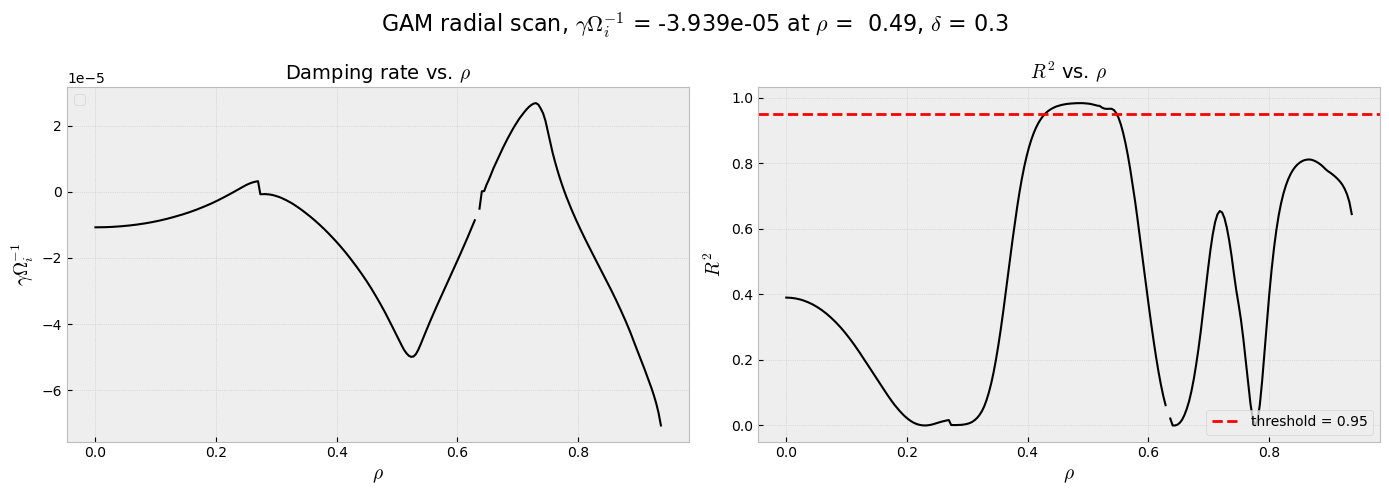

In [4]:
physical_data, statistical_data = damping.scan_gam_damping_over_radius(
	perturbed_case_data_arrays,
	dt_diag,
	jacobian_dictionary,
	GAM_frequency,
	quiescent_phi2D_list = quiescent_case_data_arrays,
	skip_peaks = [1, 3]);
print(f"Damping rate: {statistical_data["best_growth_rate"]}")
damping.plot_gam_damping_radial_scan(physical_data, statistical_data, title_suffix = r"$\delta$ = 0.3");

Setting minimum distance for interpolation to be  12.7 in code units.
Found 47 peaks.
Plotting...


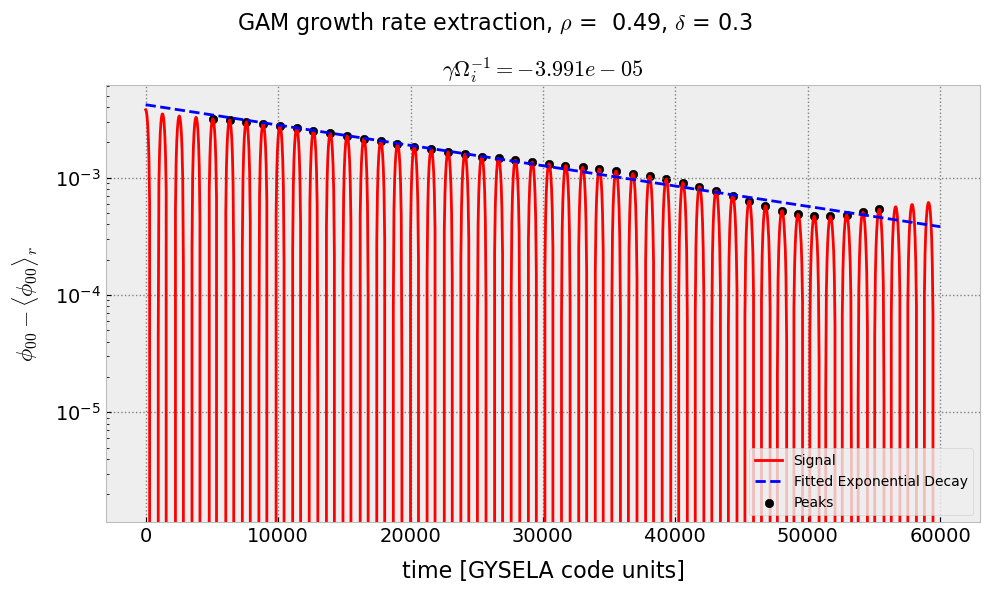

Actual damping rate: -3.991182513958519e-05


In [6]:
damping_rate = damping.plot_gam_damping(
	perturbed_case_data_arrays, 
	dt_diag, 
	jacobian_dictionary, 
	GAM_frequency, 
	effective_radius = effective_radius_simple, 
	quiescent_phi2D_list = quiescent_case_data_arrays, 
	skip_peaks = [3, 3],
	title_suffix = r"$\delta$ = 0.3");

print(f"Actual damping rate: {damping_rate}")

In [9]:
frequencies = [0.004854950845181229, 0.0049595834064997905, 0.004938656894236078, 0.004938656894236078, 0.0049177303819723656, 0.004938656894236078, 0.0049595834064997905];
damping_rates = [-5.2666452256160304e-05, -2.8728660491516704e-05, -3.3238539668768274e-05, -3.134462987930913e-05, -3.3195032079031986e-05, -3.403941091398771e-05, -3.991182513958519e-05];
delta_values = [-0.3, -0.2, -0.1, 0.0, 0.1, 0.2, 0.3];

In [7]:
def plot_parameter_scan_results(frequencies, damping_rates, parameter_values, parameter_label, title_suffix):

	canvas, frequency_plot = plt.subplots(figsize = (10, 5));

	frequency_colour = "#2c7fb8";
	frequency_plot.set_xlabel(parameter_label, fontsize = 12, fontweight = "bold");
	frequency_plot.set_ylabel('$\omega_{GAM}$', color = frequency_colour, fontsize = 12);
	frequency_line = frequency_plot.plot(parameter_values, frequencies, marker = "o", markersize = 8, color = frequency_colour, linewidth = 2.5, label = "Frequency");
	frequency_plot.tick_params(axis = "y", labelcolor = frequency_colour);
	frequency_plot.grid(True, linestyle = "--", alpha = 0.2);

	damping_plot = frequency_plot.twinx();
	damping_colour = "#d95f02";
	damping_plot.set_ylabel("$\gamma$", color = damping_colour, fontsize = 12);
	damping_line = damping_plot.plot(parameter_values, np.abs(damping_rates), marker = "s", markersize = 8, color = damping_colour, linestyle = '--', linewidth = 2, label = "Damping Rate");
	damping_plot.tick_params(axis='y', labelcolor = damping_colour);

	lines = frequency_line + damping_line;
	labels = [line.get_label() for line in lines];
	frequency_plot.legend(lines, labels, loc='lower right', frameon = True, shadow = True);

	plt.title(rf"Parameter scan ({parameter_label}), {title_suffix}", fontsize = 14, pad = 20);
	canvas.tight_layout();
	plt.show();

<>:7: SyntaxWarning: invalid escape sequence '\o'
<>:14: SyntaxWarning: invalid escape sequence '\g'
<>:7: SyntaxWarning: invalid escape sequence '\o'
<>:14: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_1536851/2166065294.py:7: SyntaxWarning: invalid escape sequence '\o'
  frequency_plot.set_ylabel('$\omega_{GAM}$', color = frequency_colour, fontsize = 12);
/tmp/ipykernel_1536851/2166065294.py:14: SyntaxWarning: invalid escape sequence '\g'
  damping_plot.set_ylabel("$\gamma$", color = damping_colour, fontsize = 12);


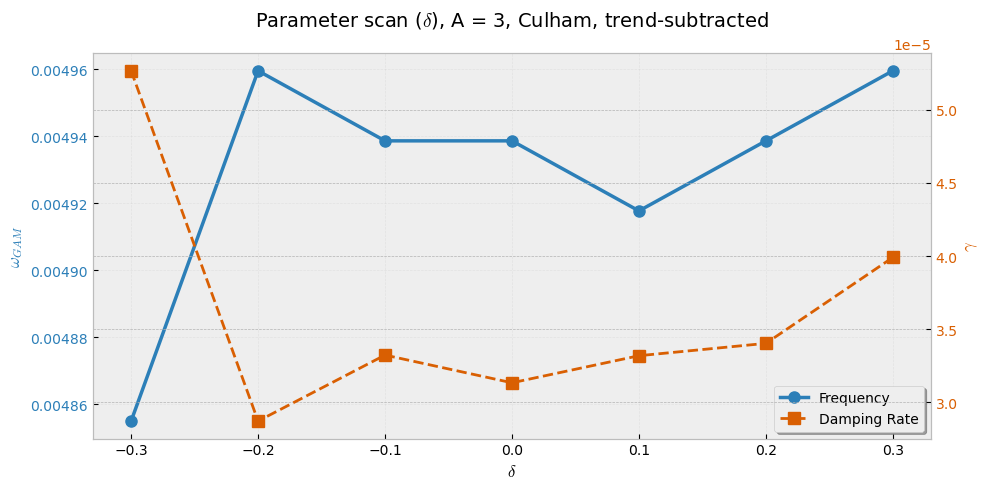

In [10]:
plot_parameter_scan_results(frequencies, damping_rates, delta_values, parameter_label = rf"$\delta$", title_suffix = "A = 3, Culham, trend-subtracted")